# MNIST Classification Demo

Demonstrates two classifiers (Random Forest, Feed-Forward NN) through the unified `MnistClassifier` interface.

CNN will be added later.

## 1. Setup and Data Loading

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mnist_classifier import MnistClassifier

In [3]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist.data.astype(np.float32), mnist.target.astype(int)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (60000, 784), Test: (10000, 784)


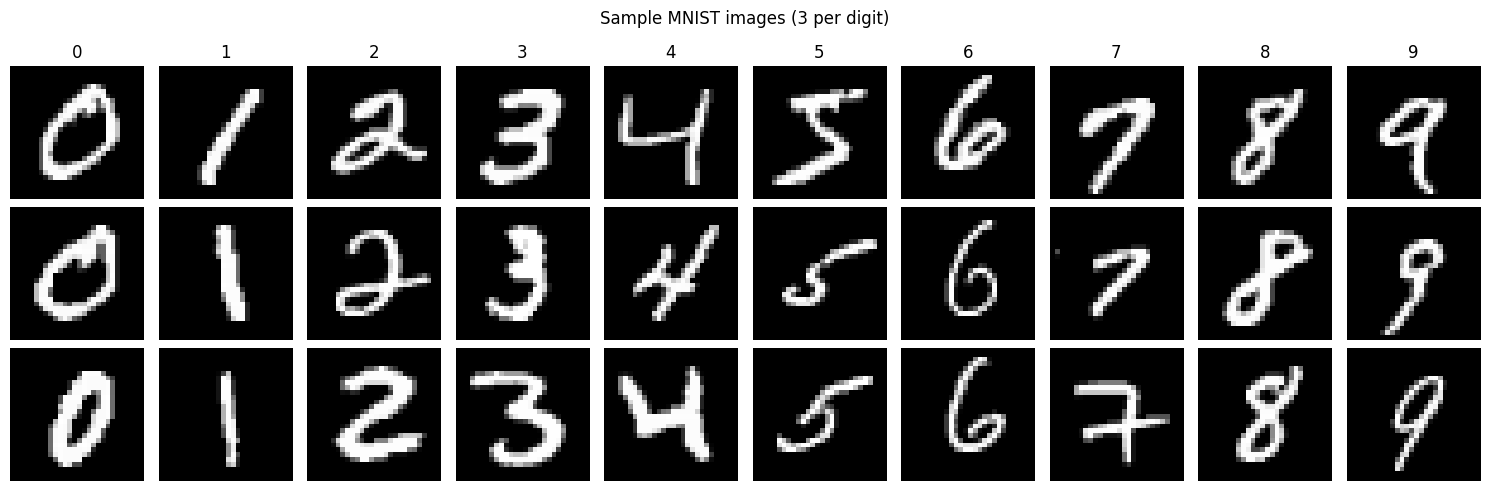

In [4]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for digit in range(10):
    idxs = np.where(y_train == digit)[0][:3]
    for row, idx in enumerate(idxs):
        axes[row, digit].imshow(X_train[idx].reshape(28, 28), cmap="gray")
        axes[row, digit].axis("off")
        if row == 0:
            axes[row, digit].set_title(str(digit))
plt.suptitle("Sample MNIST images (3 per digit)")
plt.tight_layout()
plt.show()

In [5]:
unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution (train):")
for cls, cnt in zip(unique, counts):
    print(f"  Digit {cls}: {cnt} samples")

Class distribution (train):
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


## 2. Train Models

In [7]:
algos = ["rf", "ffnn"]
results = {}

for algo in algos:
    print(f"\n{'='*40}")
    print(f"Training: {algo.upper()}")
    print('='*40)
    clf = MnistClassifier(algo)

    t0 = time.time()
    clf.train(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    preds = clf.predict(X_test)
    infer_time = time.time() - t0

    acc = accuracy_score(y_test, preds)
    results[algo] = {
        "clf": clf,
        "preds": preds,
        "accuracy": acc,
        "train_time": train_time,
        "infer_time": infer_time,
    }
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  Train time:      {train_time:.1f}s")
    print(f"  Inference time:  {infer_time:.3f}s")


Training: RF
RandomForest training completed.
  Accuracy:        0.9689
  Train time:      8.6s
  Inference time:  0.141s

Training: FFNN
Epoch 1/20 - loss: 0.2626
Epoch 2/20 - loss: 0.1210
Epoch 3/20 - loss: 0.0933
Epoch 4/20 - loss: 0.0821
Epoch 5/20 - loss: 0.0742
Epoch 6/20 - loss: 0.0654
Epoch 7/20 - loss: 0.0583
Epoch 8/20 - loss: 0.0570
Epoch 9/20 - loss: 0.0524
Epoch 10/20 - loss: 0.0505
Epoch 11/20 - loss: 0.0496
Epoch 12/20 - loss: 0.0451
Epoch 13/20 - loss: 0.0445
Epoch 14/20 - loss: 0.0451
Epoch 15/20 - loss: 0.0417
Epoch 16/20 - loss: 0.0408
Epoch 17/20 - loss: 0.0406
Epoch 18/20 - loss: 0.0402
Epoch 19/20 - loss: 0.0393
Epoch 20/20 - loss: 0.0390
  Accuracy:        0.9822
  Train time:      98.6s
  Inference time:  0.158s


## 3. Evaluation

In [8]:
print(f"{'Algorithm':<12} {'Accuracy':>10} {'Train (s)':>12} {'Infer (s)':>12}")
print("-" * 48)
for algo, r in results.items():
    print(f"{algo.upper():<12} {r['accuracy']:>10.4f} {r['train_time']:>12.1f} {r['infer_time']:>12.3f}")

Algorithm      Accuracy    Train (s)    Infer (s)
------------------------------------------------
RF               0.9689          8.6        0.141
FFNN             0.9822         98.6        0.158


In [9]:
for algo, r in results.items():
    print(f"\n--- {algo.upper()} Classification Report ---")
    print(classification_report(y_test, r["preds"], digits=4))


--- RF Classification Report ---
              precision    recall  f1-score   support

           0     0.9709    0.9878    0.9793       980
           1     0.9894    0.9894    0.9894      1135
           2     0.9579    0.9709    0.9644      1032
           3     0.9632    0.9594    0.9613      1010
           4     0.9724    0.9695    0.9709       982
           5     0.9762    0.9652    0.9707       892
           6     0.9730    0.9791    0.9761       958
           7     0.9735    0.9640    0.9687      1028
           8     0.9587    0.9528    0.9557       974
           9     0.9522    0.9485    0.9503      1009

    accuracy                         0.9689     10000
   macro avg     0.9688    0.9687    0.9687     10000
weighted avg     0.9689    0.9689    0.9689     10000


--- FFNN Classification Report ---
              precision    recall  f1-score   support

           0     0.9878    0.9918    0.9898       980
           1     0.9877    0.9938    0.9908      1135
        

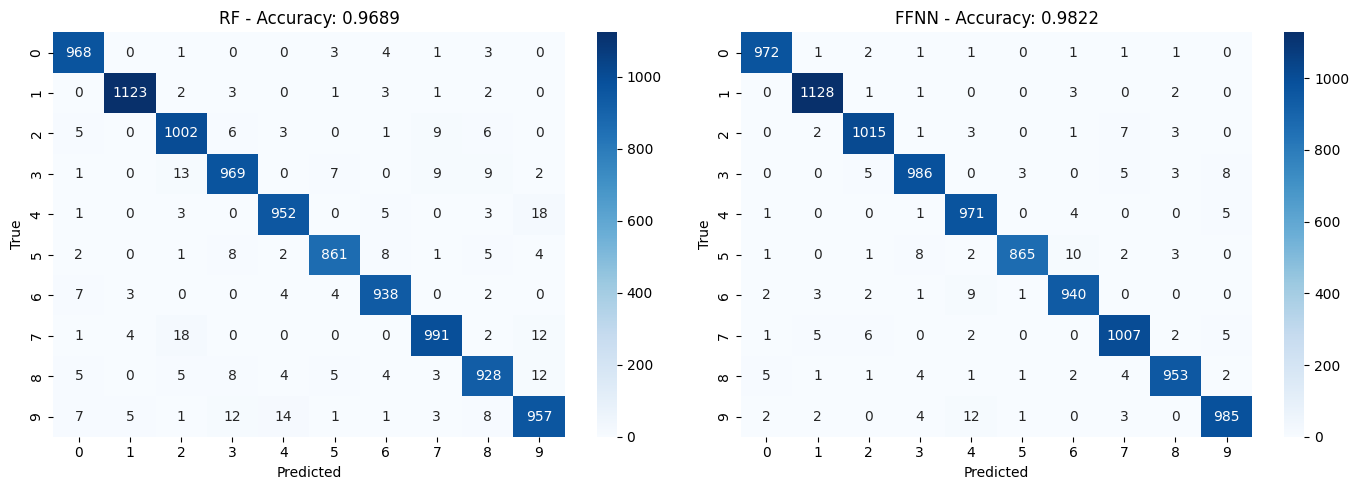

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (algo, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(f"{algo.upper()} - Accuracy: {r['accuracy']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

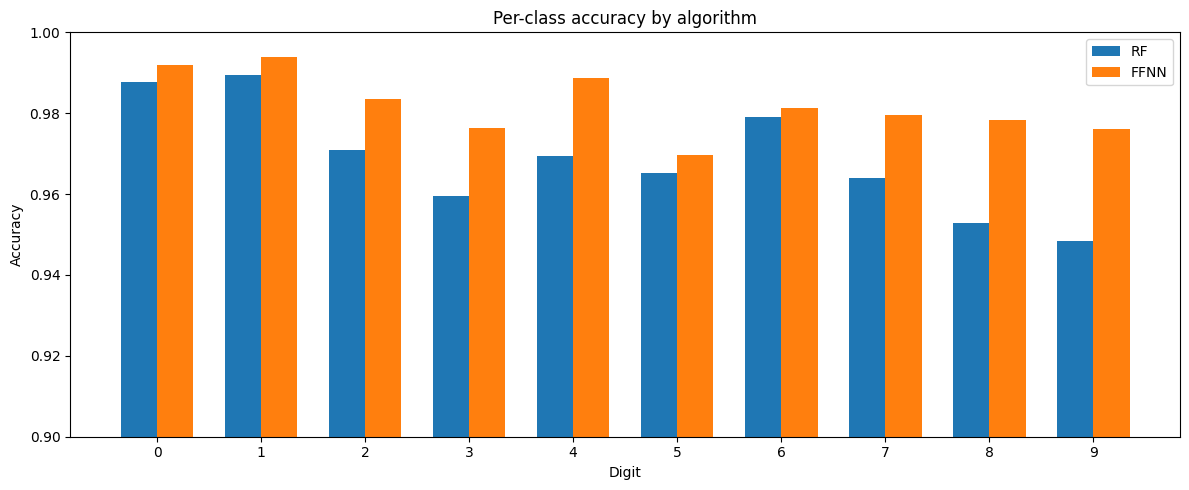

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(10)
width = 0.35
for i, (algo, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    ax.bar(x + i * width, per_class_acc, width, label=algo.upper())
ax.set_xticks(x + width / 2)
ax.set_xticklabels(range(10))
ax.set_xlabel("Digit")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.9, 1.0)
ax.set_title("Per-class accuracy by algorithm")
ax.legend()
plt.tight_layout()
plt.show()

## 4. OOP Interface Demonstration

In [12]:
from interface import MnistClassifierInterface

for algo in algos:
    clf = MnistClassifier(algo)
    is_impl = isinstance(clf._classifier, MnistClassifierInterface)
    print(f"{algo.upper()} implements MnistClassifierInterface: {is_impl}")

RF implements MnistClassifierInterface: True
FFNN implements MnistClassifierInterface: True


In [15]:
sample = X_test[:5]
print(f"Input shape: {sample.shape}")
for algo in algos:
    print()
    clf = MnistClassifier(algo)
    clf.train(X_train[:1000], y_train[:1000])
    preds = clf.predict(sample)
    print(f"{algo.upper()} output: {preds}  shape={preds.shape}  dtype={preds.dtype}")

Input shape: (5, 784)

RandomForest training completed.
RF output: [7 2 1 0 4]  shape=(5,)  dtype=int64

Epoch 1/20 - loss: 1.8948
Epoch 2/20 - loss: 1.0689
Epoch 3/20 - loss: 0.5558
Epoch 4/20 - loss: 0.3050
Epoch 5/20 - loss: 0.1820
Epoch 6/20 - loss: 0.1020
Epoch 7/20 - loss: 0.0693
Epoch 8/20 - loss: 0.0453
Epoch 9/20 - loss: 0.0291
Epoch 10/20 - loss: 0.0210
Epoch 11/20 - loss: 0.0126
Epoch 12/20 - loss: 0.0109
Epoch 13/20 - loss: 0.0109
Epoch 14/20 - loss: 0.0073
Epoch 15/20 - loss: 0.0065
Epoch 16/20 - loss: 0.0076
Epoch 17/20 - loss: 0.0059
Epoch 18/20 - loss: 0.0049
Epoch 19/20 - loss: 0.0040
Epoch 20/20 - loss: 0.0045
FFNN output: [7 6 1 0 4]  shape=(5,)  dtype=int64


## 5. Edge Cases

### 5.1 Invalid algorithm

In [17]:
try:
    clf = MnistClassifier("svm")
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Unsupported algorithm 'svm'. Supported algorithms: ['rf', 'ffnn']


### 5.2 Predict before train

In [18]:
for algo in algos:
    clf = MnistClassifier(algo)
    try:
        clf.predict(X_test[:5])
        print(f"{algo} should have raised RuntimeError")
    except RuntimeError as e:
        print(f"{algo.upper()} RuntimeError: {e}")

RF RuntimeError: Model is not trained yet. Call train() before predict().
FFNN RuntimeError: Model is not trained yet. Call train() before predict().


### 5.3 Single sample prediction (batch size 1)

In [19]:
single = X_test[[0]]  # shape (1, 784)
true_label = y_test[0]
print(f"Input shape: {single.shape}, True label: {true_label}")

for algo, r in results.items():
    pred = r["clf"].predict(single)
    print(f"{algo.upper()} prediction: {pred[0]}  (correct: {pred[0] == true_label})")

Input shape: (1, 784), True label: 7
RF prediction: 7  (correct: True)
FFNN prediction: 7  (correct: True)


### 5.4 All-zero image (blank canvas)

In [28]:
# No crash - may predict any class since blank images are out-of-distribution
blank = np.zeros((1, 784), dtype=np.float32)
print("Predictions on a blank (all-zero) image:")
for algo, r in results.items():
    pred = r["clf"].predict(blank)
    print(f"  {algo.upper()}: {pred[0]}")

Predictions on a blank (all-zero) image:
  RF: 7
  FFNN: 1


### 5.5 All-white image (max pixel values)

In [30]:
# No crash - out-of-distribution input handled gracefully
white = np.full((1, 784), 255.0, dtype=np.float32)
print("Predictions on an all-white (255) image:")
for algo, r in results.items():
    pred = r["clf"].predict(white)
    print(f"  {algo.upper()}: {pred[0]}")

Predictions on an all-white (255) image:
  RF: 0
  FFNN: 8


### 5.6 Random noise image

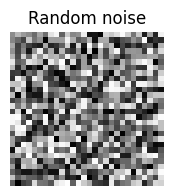

Predictions on random noise:


  RF: 8
  FFNN: 8
(No crash - models still produce a prediction, but it's meaningless)


In [ ]:
#No crash - models still produce a prediction, but it's meaningless

rng = np.random.RandomState(0)
noise = rng.rand(1, 784).astype(np.float32) * 255

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax.imshow(noise.reshape(28, 28), cmap="gray")
ax.set_title("Random noise")
ax.axis("off")
plt.show()

print("Predictions on random noise:")
for algo, r in results.items():
    pred = r["clf"].predict(noise)
    print(f"  {algo.upper()}: {pred[0]}")

### 5.7 Hyperparameter forwarding via kwargs

In [18]:
clf_rf = MnistClassifier("rf", n_estimators=50, max_depth=10)
print(f"RF n_estimators: {clf_rf._classifier._model.n_estimators}")  # 50
print(f"RF max_depth:    {clf_rf._classifier._model.max_depth}")     # 10

clf_nn = MnistClassifier("ffnn", epochs=2, batch_size=256)
print(f"NN epochs:       {clf_nn._classifier._epochs}")              # 2
print(f"NN batch_size:   {clf_nn._classifier._batch_size}")          # 256

RF n_estimators: 50
RF max_depth:    10
NN epochs:       2
NN batch_size:   256


### 5.8 Batch of identical images

In [19]:
# 10 copies of the same image should all get the same prediction
repeated = np.tile(X_test[0], (10, 1))  # shape (10, 784)
print(f"Input: 10 copies of the same image, shape {repeated.shape}")
for algo, r in results.items():
    preds = r["clf"].predict(repeated)
    all_same = len(set(preds)) == 1
    print(f"  {algo.upper()}: {preds} - all same: {all_same}")

Input: 10 copies of the same image, shape (10, 784)
  RF: [7 7 7 7 7 7 7 7 7 7] - all same: True
  FFNN: [7 7 7 7 7 7 7 7 7 7] - all same: True
